# Data Analysis : UMAP ANNOTATIONS


**AIMS**  
1.Understanding the Disease
What is HGSOC, and why does it spread in the peritoneal cavity?
Why is peritoneal carcinomatosis hard to treat?
What is the tumor microenvironment (TME)?
What is platinum resistance?

2.Understanding the Data
What do the data types provide?
Why is spatial context important?
Key features from each dataset?

3. Characterizing the TME
How to identify immune cells?
How to define spatial regions?
Indicators of immune states?
How to detect spatial heterogeneity?

4. Linking to Disease Mechanisms
Patterns explaining resistance?
Tumor–immune interactions?
Patient comparison (hypothetical):

5. Results & Interpretation
Key spatial patterns?
Findings linked to aggressiveness/resistance?
Main biological insight?
Therapeutic implications?

In [ ]:
import scanpy as sc
import squidpy as sq
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import h5py
from pathlib import Path
from scipy import sparse
import anndata
import seaborn as sns

***<center>Do I want to analyze patient A1 or D1 : Choose your Boolean and get the corresponding graph***

In [124]:
a1 = True
d1 = False

In [125]:
current_path = Path.cwd()


if a1:
    # File Path for A1
    file_path = current_path / "A1" / "outs" / "binned_outputs" / "square_008um" / "filtered_feature_bc_matrix.h5"
    differential_expression_path = current_path / "A1" / "outs" / "binned_outputs" / "square_008um" / "analysis" / "diffexp" / "gene_expression_graphclust" / "differential_expression.csv"
    clusters_path = current_path / "A1" / "outs" / "binned_outputs" / "square_008um" / "analysis" / "clustering" / "gene_expression_graphclust" / "clusters.csv"
    tissue_positions_path = current_path / "A1" / "outs" / "binned_outputs" / "square_008um" / "spatial" / "tissue_positions.parquet"
    
if d1:
    print("current_path:", current_path)
    # File Path for D1
    file_path = current_path / "D1" / "outs" / "binned_outputs" / "square_008um" /  "filtered_feature_bc_matrix.h5"
    differential_expression_path = current_path / "D1" / "outs" / "binned_outputs" / "square_008um" / "analysis" / "diffexp" / "gene_expression_graphclust" / "differential_expression.csv"
    clusters_path = current_path / "D1" / "outs" / "binned_outputs" / "square_008um" / "analysis" / "clustering" / "gene_expression_graphclust" / "clusters.csv"
    tissue_positions_path = current_path / "D1" / "outs" / "binned_outputs" / "square_008um" / "spatial" / "tissue_positions.parquet"



with h5py.File(file_path, "r") as f:
    print(list(f.keys()))  # shows top-level groups/datasets

with h5py.File(file_path, "r") as f:
    print(list(f["matrix"].keys()))

['matrix']
['barcodes', 'data', 'features', 'indices', 'indptr', 'shape']


In [126]:
with h5py.File(file_path, "r") as f:
    data = f["matrix/data"][:]
    indices = f["matrix/indices"][:]
    indptr = f["matrix/indptr"][:]
    shape = f["matrix/shape"][:]

# Build sparse count matrix
matrix = sparse.csc_matrix((data, indices, indptr), shape=shape)
print(matrix.shape)

(38606, 167450)


In [127]:
adata = anndata.AnnData(X=matrix.T)  # usually transpose: cells × genes

In [128]:
# Load CSVs
diffexp_df = pd.read_csv(differential_expression_path)
clusters_df = pd.read_csv(clusters_path)

# Preview
diffexp_df

,Feature ID,Feature Name,Cluster 1 Mean Counts,Cluster 1 Log2 fold change,Cluster 1 Adjusted p value,Cluster 2 Mean Counts,Cluster 2 Log2 fold change,Cluster 2 Adjusted p value,Cluster 3 Mean Counts,Cluster 3 Log2 fold change,Cluster 3 Adjusted p value,Cluster 4 Mean Counts,Cluster 4 Log2 fold change,Cluster 4 Adjusted p value,Cluster 5 Mean Counts,Cluster 5 Log2 fold change,Cluster 5 Adjusted p value
0,ENSG00000238009,ENSG00000238009,0.000042,2.171718,2.305574e-01,0.000000,-1.211420,5.090305e-01,0.000000,2.440397,1.000000,0.000000,0.879356,1.000000,0.000000,3.031347,1.0
1,ENSG00000291215,ENSG00000291215,0.000727,1.912074,1.077689e-06,0.000121,-2.211420,1.110393e-05,0.000000,-1.680619,0.805163,0.000501,0.237810,1.000000,0.000000,-1.089669,1.0
2,ENSG00000237491,LINC01409,0.000083,0.019715,1.000000e+00,0.000121,0.940583,4.765922e-01,0.000000,0.762325,1.000000,0.000000,-0.798716,0.768209,0.000000,1.353275,1.0
3,ENSG00000290784,ENSG00000290784,0.000010,-0.735173,7.495938e-01,0.000017,0.525546,1.000000e+00,0.000000,2.762325,1.000000,0.000056,2.616322,0.593622,0.000000,3.353275,1.0
4,ENSG00000177757,FAM87B,0.000000,-1.150210,6.267450e-01,0.000000,0.110508,1.000000e+00,0.000154,5.762325,0.605730,0.000000,2.201284,1.000000,0.000000,4.353275,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22771,ENSG00000273748,ENSG00000273748,0.000042,-0.828282,5.466988e-01,0.000086,0.888116,5.409140e-01,0.000000,1.177362,1.000000,0.000056,0.741853,1.000000,0.000229,2.893843,1.0
22772,ENSG00000271254,ENSG00000271254,0.000073,1.264827,3.199077e-01,0.000017,-1.059417,5.043690e-01,0.000000,1.440397,1.000000,0.000056,1.031359,0.996609,0.000000,2.031347,1.0
22773,ENSG00000276345,ENSG00000276345,0.000031,0.264827,1.000000e+00,0.000035,0.695471,8.475932e-01,0.000000,2.177362,1.000000,0.000000,0.616322,1.000000,0.000000,2.768312,1.0
22774,ENSG00000273554,ENSG00000273554,0.000706,3.636386,1.148400e-12,0.000035,-3.454276,6.193221e-08,0.000307,0.197540,1.000000,0.000000,-2.988540,0.014041,0.000000,-0.836550,1.0


In [129]:
positions_df = pd.read_parquet(tissue_positions_path)
positions_df

,barcode,in_tissue,array_row,array_col,pxl_row_in_fullres,pxl_col_in_fullres
0,s_008um_00000_00000-1,0,0,0,19858.364069,23765.912365
1,s_008um_00000_00001-1,0,0,1,19826.304160,23766.766875
2,s_008um_00000_00002-1,0,0,2,19794.244252,23767.621384
3,s_008um_00000_00003-1,0,0,3,19762.184345,23768.475893
4,s_008um_00000_00004-1,0,0,4,19730.124439,23769.330402
...,...,...,...,...,...,...
702239,s_008um_00837_00833-1,0,837,833,-7562.274481,-2357.447094
702240,s_008um_00837_00834-1,0,837,834,-7594.334537,-2356.592158
702241,s_008um_00837_00835-1,0,837,835,-7626.394593,-2355.737221
702242,s_008um_00837_00836-1,0,837,836,-7658.454647,-2354.882285


In [130]:
# Ensure matching column names
clusters_df = clusters_df.rename(columns={"Barcode": "barcode"})

# save clusters_df to a new CSV file
clusters_df.to_csv(current_path / "A1" / "outs" / "binned_outputs" / "square_008um" / "analysis" / "clustering" / "gene_expression_graphclust" / "clusters_renamed.csv", index=False)

# Merge spatial coords + cluster labels
plot_df = positions_df.merge(clusters_df, on="barcode", how="inner")

# (Optional) keep only spots in tissue
plot_df = plot_df[plot_df["in_tissue"] == 1]

In [131]:
clusters_df.head()

,barcode,Cluster
0,s_008um_00357_00397-1,2
1,s_008um_00260_00253-1,2
2,s_008um_00466_00453-1,1
3,s_008um_00474_00251-1,2
4,s_008um_00266_00304-1,2


In [132]:
# For each cluster, count how many spots belong to it, then compute the percentage of total spots for each cluster
cluster_counts = plot_df["Cluster"].value_counts()
cluster_percentages = cluster_counts / cluster_counts.sum() * 100

In [133]:
# Custom color palette 

n_clusters = plot_df["Cluster"].nunique()
cluster_ids = sorted(plot_df["Cluster"].unique())

if a1:
    custom_palette = {
        cluster_ids[0]: "#AD1E13",   # cancer
        cluster_ids[1]: "#F25858",   # Mesenchymal
        cluster_ids[2]: "#979797",   # Unknwonw
        cluster_ids[3]: "#09F411",   # Macrophage
        cluster_ids[4]: "#2FC9F8",   # Endothelial
    }


    
if d1:
    custom_palette = {
        cluster_ids[0]: "#FF00D0",   # Epithelial Cell, Cancer is epithelial and color pattern should highligh their similaratty
        cluster_ids[1]: "#7C7C7C",   # Unknown compare to 1
        cluster_ids[2]: "#AD1E13",   # Cancer Cell compare to 1
        cluster_ids[3]: "#F25858",   # Mesenchymal Cell Compare to 1
        cluster_ids[4]: "#2FC9F8",   # Endothelial Cell Compare to 1
        cluster_ids[5]: "#09F411",   # Macrophage Compare to 1
        cluster_ids[6]: "#CFD960",   # B Cell
        cluster_ids[7]: "#EEFF00",   # B Cell Also
        cluster_ids[8]: "#C013E3"   # Unknown, 
    }

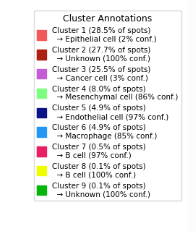

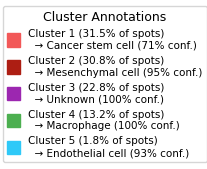

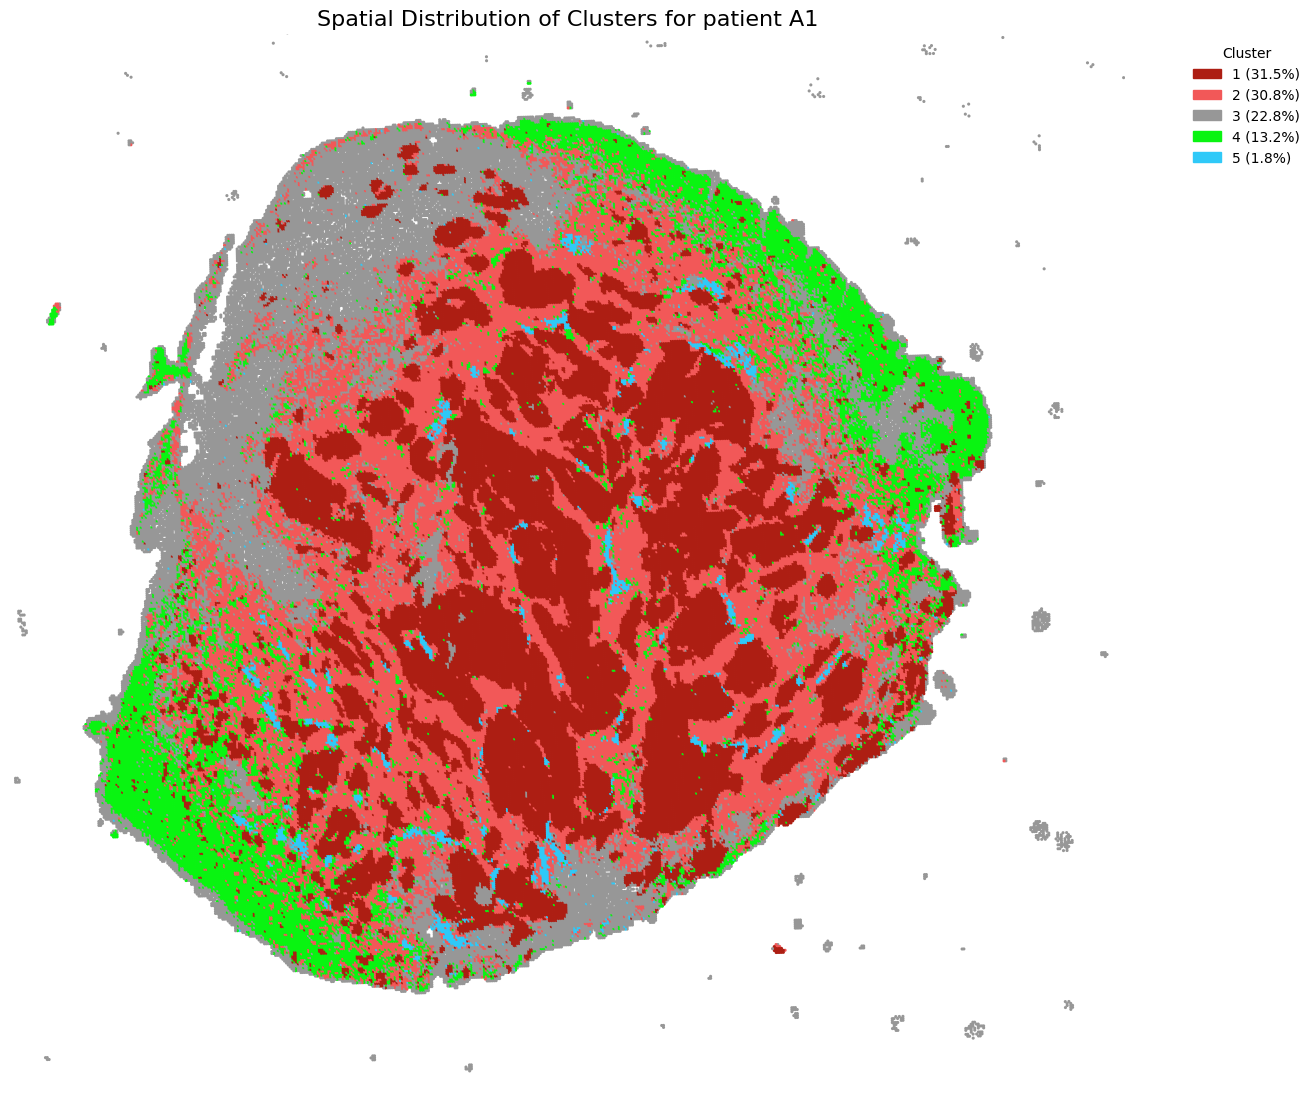

In [134]:
from matplotlib.pyplot import savefig
import matplotlib.patches as mpatches


plt.figure(figsize=(15, 6))
sns.scatterplot(
    data=plot_df,
    x="pxl_col_in_fullres",
    y="pxl_row_in_fullres",
    hue="Cluster",
    palette=custom_palette,
    s=5,
    linewidth=0
)
plt.gca().invert_yaxis()  # image-style orientation
plt.axis()
plt.tight_layout()
if a1:
    plt.xlim(0, 20000)
    plt.ylim(0, 17000)


handles = [
    mpatches.Patch(
        color=custom_palette[cluster],
        label=f"{cluster} ({cluster_percentages[cluster]:.1f}%)"
    )
    for cluster in sorted(custom_palette.keys())  # sorted by cluster ID
]

plt.legend(
    handles=handles,
    title="Cluster",
    markerscale=10,
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    frameon=False,
)
plt.axis("off")
plt.gcf().set_size_inches(12, 12)

if a1:
    plt.title("Spatial Distribution of Clusters for patient A1", fontsize=16)
    plt.savefig(current_path / "figure" / "spatial_clusters_A1.png", bbox_inches="tight")
else:
    plt.title("Spatial Distribution of Clusters for patient D1", fontsize=16)
    plt.savefig(current_path / "figure" / "spatial_clusters_D1.png", bbox_inches="tight")  
plt.show()


### UMAP

In [135]:
# rename column barcode as Barcode
clusters_df = clusters_df.rename(columns={"barcode": "Barcode"})
clusters_df.head(9)

,Barcode,Cluster
0,s_008um_00357_00397-1,2
1,s_008um_00260_00253-1,2
2,s_008um_00466_00453-1,1
3,s_008um_00474_00251-1,2
4,s_008um_00266_00304-1,2
5,s_008um_00645_00294-1,3
6,s_008um_00539_00265-1,1
7,s_008um_00385_00435-1,1
8,s_008um_00469_00254-1,1


In [136]:
"""# 0) Quick debug: see what clusters exist vs palette keys
print("palette keys      :", sorted(custom_palette_2.keys()))
print("clusters in umap  :", sorted(umap_df["Cluster"].unique()))
print("missing in palette:",
      sorted(set(umap_df["Cluster"].unique()) - set(custom_palette_2.keys())))"""

'# 0) Quick debug: see what clusters exist vs palette keys\nprint("palette keys      :", sorted(custom_palette_2.keys()))\nprint("clusters in umap  :", sorted(umap_df["Cluster"].unique()))\nprint("missing in palette:",\n      sorted(set(umap_df["Cluster"].unique()) - set(custom_palette_2.keys())))'

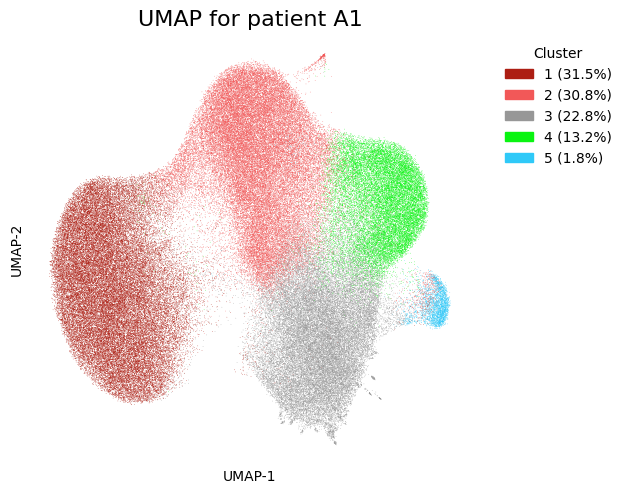

In [137]:
# load path to UMAP : C:\MA2\Hackaton\Ovarian-Cancer-Tumor-Microenvironment\D1\outs\binned_outputs\square_008um\analysis\umap\gene_expression_2_components

# Load UMAP
if a1:
    umap_path = current_path / "A1" / "outs" / "binned_outputs" / "square_008um" / "analysis" / "umap" / "gene_expression_2_components" / "projection.csv"
if d1:
    umap_path = current_path / "D1" / "outs" / "binned_outputs" / "square_008um" / "analysis" / "umap" / "gene_expression_2_components" / "projection.csv"

umap_df = pd.read_csv(umap_path, index_col=0)

# IMPORTANT: add cluster labels
umap_df = umap_df.merge(clusters_df, on="Barcode", how="inner")
# Build palette from *actual* clusters in umap_df
clusters = sorted(umap_df["Cluster"].unique())


import matplotlib.patches as mpatches

clusters = sorted(umap_df["Cluster"].unique())

# Build legend handles directly from the palette dict
handles = []
for c in clusters:
    label = f"{c} ({cluster_percentages[c]:.1f}%)"
    handles.append(mpatches.Patch(color=custom_palette.get(c, "#999999"), label=label))

sns.scatterplot(
    data=umap_df,
    x="UMAP-1",
    y="UMAP-2",
    hue="Cluster",
    hue_order=clusters,
    palette=custom_palette,
    s=0.2,
    linewidth=0,
    legend=False,   # <‑‑ critical: prevent Seaborn from making its own legend
)

plt.legend(
    handles=handles,
    title="Cluster",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    frameon=False,
)

ax = plt.gca()
ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
if a1:
    plt.title("UMAP for patient A1", fontsize=16)
    plt.savefig(current_path / "figure" / "umap_clusters_A1.png", bbox_inches="tight")
if d1:
    plt.title("UMAP for patient D1", fontsize=16)
    plt.savefig(current_path / "figure" / "umap_clusters_D1.png", bbox_inches="tight")

plt.show()

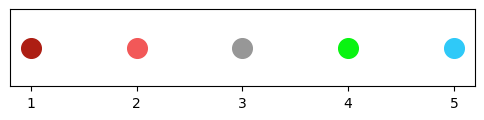

In [138]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 1))
for i, c in enumerate(clusters):
    _pal = custom_palette if "custom_palette" in globals() else globals().get("palette", {})
    plt.scatter(i, 0, color=_pal.get(c, _pal.get(int(c), "#999999")), s=200)
plt.xticks(range(len(clusters)), clusters)
plt.yticks([])
plt.show()

# Cluster Annotation Pipeline

## Overview

This pipeline identifies the most likely cell type for each spatial transcriptomics cluster by matching differentially expressed (DE) genes against a curated marker database. The result is a confidence score per cell type per cluster, visualized as a dot plot.



## Pipeline Steps

### Step 1 : Load the Marker Database

A curated biological database maps known **marker genes** to **cell types**:

| cell_type  | gene  |
|------------|-------|
| Macrophage | CD68  |
| Macrophage | MRC1  |
| B cell     | CD19  |
| Cancer cell| EPCAM |

Only markers whose genes are present in the spatial dataset are kept (`marker_dict_filtered`).



### Step 2 : Build the Weight Matrix W

```
W  shape:  (n_genes × n_cell_types)
           ~30,000  ×  ~50
```

Each known (gene → cell type) association fills a cell in W with `1.0`. This matrix is a **lookup table**: given a gene, which cell types does it point to?

```
         Macrophage  B cell  Cancer cell  ...
CD68   [    1.0        0.0      0.0      ]
CD19   [    0.0        1.0      0.0      ]
EPCAM  [    0.0        0.0      1.0      ]
...
```



### Step 3 : Weight the DE Genes of Each Cluster

For each cluster, DE genes from `diffexp_df` are assigned a biological weight:

```
weight = LFC × -log10(adjusted_p_value)
```

| Component | Meaning |
|-----------|---------|
| **LFC** (Log2 Fold Change) | How strongly overexpressed is this gene vs. other clusters? |
| **-log10(p-value)** | How statistically confident are we? |

> Genes with **negative LFC** are clipped to 0 — only upregulated genes contribute.  
> A gene with LFC=3 and p=1e-10 carries far more weight than one with LFC=0.5 and p=0.04.



### Step 4 : Score Each Cluster Against All Cell Types

For each DE gene in a cluster, its weight is distributed across all cell types it marks (via W):

```
score_vec += gene_weight × W[gene_index, :]
```

**Example for Macrophage:**
```
score[Macrophage] = weight(CD68) × W[CD68, Macrophage]
                  + weight(MRC1) × W[MRC1, Macrophage]
                  + ...
```

After iterating over all DE genes, each cell type has a raw score reflecting how much marker evidence points to it.



### Step 5 : Normalize to Percentages

Raw scores are converted to percentages summing to 100%:

```
confidences = (raw_scores / raw_scores.sum()) * 100
```

This is a direct, honest normalization — no artificial sharpening. A score of 60% means **60% of the total marker evidence** points to that cell type.



### Step 6 : Rank Results

Cell types are ranked by confidence for each cluster:

```
Cluster 4:
  1. Macrophage        62.3%  ██████████████████████████████
  2. Myeloid cell      18.1%  █████████
  3. Cancer cell        9.4%  ████
```

If no DE gene overlaps with any marker, the cluster is labeled **Unknown**.



### Step 7 : Visualize as a Dot Plot

The top 3 cell types per cluster are displayed in a dot plot encoding two dimensions simultaneously:

| Visual property | Meaning |
|-----------------|---------|
| **Dot size**    | Relative confidence within that cluster (normalized to its own max) |
| **Dot color**   | Absolute confidence % — red = high, blue = low |

## Let's get for each gene the one with differential gene expression with p-value < 0.05

In [139]:
diffexp_df.head()

,Feature ID,Feature Name,Cluster 1 Mean Counts,Cluster 1 Log2 fold change,Cluster 1 Adjusted p value,Cluster 2 Mean Counts,Cluster 2 Log2 fold change,Cluster 2 Adjusted p value,Cluster 3 Mean Counts,Cluster 3 Log2 fold change,Cluster 3 Adjusted p value,Cluster 4 Mean Counts,Cluster 4 Log2 fold change,Cluster 4 Adjusted p value,Cluster 5 Mean Counts,Cluster 5 Log2 fold change,Cluster 5 Adjusted p value
0,ENSG00000238009,ENSG00000238009,0.000042,2.171718,0.230557,0.000000,-1.211420,0.509031,0.000000,2.440397,1.000000,0.000000,0.879356,1.000000,0.0,3.031347,1.0
1,ENSG00000291215,ENSG00000291215,0.000727,1.912074,0.000001,0.000121,-2.211420,0.000011,0.000000,-1.680619,0.805163,0.000501,0.237810,1.000000,0.0,-1.089669,1.0
2,ENSG00000237491,LINC01409,0.000083,0.019715,1.000000,0.000121,0.940583,0.476592,0.000000,0.762325,1.000000,0.000000,-0.798716,0.768209,0.0,1.353275,1.0
3,ENSG00000290784,ENSG00000290784,0.000010,-0.735173,0.749594,0.000017,0.525546,1.000000,0.000000,2.762325,1.000000,0.000056,2.616322,0.593622,0.0,3.353275,1.0
4,ENSG00000177757,FAM87B,0.000000,-1.150210,0.626745,0.000000,0.110508,1.000000,0.000154,5.762325,0.605730,0.000000,2.201284,1.000000,0.0,4.353275,1.0


In [140]:
with h5py.File(file_path, "r") as f:
    gene_names = f["matrix/features/name"][:].astype(str)

adata.var_names = gene_names
adata.var_names_make_unique()

In [141]:
cluster_significant_genes = {}
if a1:
    cluster_number = 5
else:
    cluster_number = 9

for cluster in range(1, cluster_number + 1):
    cluster_pvalue = f"Cluster {cluster} Adjusted p value"
    cluster_lfc    = f"Cluster {cluster} Log2 fold change"
    cluster_count  = f"Cluster {cluster} Mean Counts"

    mask = (
        (diffexp_df[cluster_pvalue] < 0.05) &        # significant
        (diffexp_df[cluster_count]  > 0.05) &        # expressed
        (diffexp_df[cluster_lfc]    > 0)    &        # upregulated in this cluster
        (~diffexp_df["Feature Name"].str.startswith("MT-")) &  # exclude mitochondrial
        (~diffexp_df["Feature Name"].str.startswith("RPS-"))  # exclude ribosomal

    )

    top40 = (
        diffexp_df[mask]
        .sort_values(cluster_lfc, ascending=False)
        .head(40)["Feature Name"]
        .tolist()
    )

    cluster_significant_genes[cluster] = top40
    print(f"Cluster {cluster}: {len(top40)} genes → {top40[:3]}")

Cluster 1: 40 genes → ['EPCAM', 'MUC1', 'CD24']
Cluster 2: 40 genes → ['COL11A1', 'SFRP4', 'COL8A1']
Cluster 3: 9 genes → ['ENSG00000289942', 'MT2A', 'TIMP1']
Cluster 4: 40 genes → ['MARCO', 'SLC11A1', 'TNFRSF1B']
Cluster 5: 22 genes → ['VWF', 'MCAM', 'CD93']


### Let's associate an identity to each of the gene using the marker

In [142]:
# Use of a online database of cell markers to identify cell types in our clusters based on their DE genes

df_human = pd.read_excel("Cell_marker_Human.xlsx", engine="openpyxl")


tissues_of_interest = ["Ovary"]

df_tme = df_human[
    df_human["tissue_type"].str.contains(
        "|".join(tissues_of_interest),
        case=False, na=False
    )
]

print(df_tme["tissue_type"].value_counts())

df_ovarian_cancer = df_human[
    df_human["cancer_type"].str.contains("Ovarian|ovarian", na=False)
]
print(df_ovarian_cancer["cancer_type"].value_counts())

# Keep only relevant column :
df_markers = df_ovarian_cancer[["cell_name", "Symbol"]].dropna()
df_markers.columns = ["cell_type", "gene"]

# Keep only markers pressent in the dataset

marker_dict = (
    df_markers.groupby("cell_type")["gene"]
    .apply(list)
    .to_dict()
)

marker_dict_filtered = {
    cell: [g for g in genes if g in adata.var_names]
    for cell, genes in marker_dict.items()
}

tissue_type
Ovary    457
Name: count, dtype: int64
cancer_type
Ovarian Cancer                           321
High-grade serous ovarian cancer          34
Ovarian clear cell carcinoma               8
Unspecified Epithelial Ovarian Cancer      7
Serous Ovarian Cancer                      5
Ovarian cancer                             4
Ovarian Adenocarcinoma                     4
Ovarian Teratocarcinoma                    3
Name: count, dtype: int64


Now that we have a dataset of marker gene and the most DEG with p-value <0.05 for each dataset. Let's finally assign an identity to each cluster

take average expression for all cluster of each gene
The pipeline : 
* Weight Matrix W (genes * cell_types)
* Cluster score Vector
* Softmax and confidence intervall control by a temperature hyperparameter

In [143]:
# ── 1. BUILD THE GENE-LEVEL WEIGHT MATRIX ────────────────────────────────────
# Each gene gets a per-cell-type weight = how strongly it marks that cell type.
# Weight  =  sum of  LFC × –log10(adj_p)  across all rows in df_markers
# where that (gene, cell_type) pair appears.  Genes not in the marker DB → 0.

all_cell_types = list(marker_dict_filtered.keys())   # columns
all_genes      = list(adata.var_names)               # rows

# Index lookups for speed
gene_index      = {g: i for i, g in enumerate(all_genes)}
celltype_index  = {ct: j for j, ct in enumerate(all_cell_types)}

# W[gene_idx, celltype_idx]  (dense float32 — manageable for ~30k genes × ~50 cell types)
W = np.zeros((len(all_genes), len(all_cell_types)), dtype=np.float32)

for _, row in df_markers.iterrows():
    gene      = row["gene"]
    cell_type = row["cell_type"]
    if gene not in gene_index or cell_type not in celltype_index:
        continue
    gi  = gene_index[gene]
    cti = celltype_index[cell_type]
    # Simple unit weight per marker entry; extend here with LFC if df_markers has it
    W[gi, cti] += 1.0

print(f"Weight matrix shape : {W.shape}  (genes × cell types)")
print(f"Non-zero entries    : {np.count_nonzero(W)}")


Weight matrix shape : (38606, 43)  (genes × cell types)
Non-zero entries    : 220


In [144]:
# ── 2. BUILD THE CLUSTER DE-GENE SCORE VECTOR ────────────────────────────────
# For each cluster we have top-40 significant genes.
# We weight each gene by  LFC × –log10(adj_p)  so highly significant,
# strongly up-regulated genes count more than borderline ones.

def cluster_gene_weights(cluster: int) -> dict:
    """Return {gene: score} for the DE genes of a cluster."""
    lfc_col = f"Cluster {cluster} Log2 fold change"
    pval_col = f"Cluster {cluster} Adjusted p value"

    sig_genes = cluster_significant_genes[cluster]
    sub = diffexp_df[diffexp_df["Feature Name"].isin(sig_genes)].copy()

    # Clip p-values to avoid log(0)
    sub["neg_log_p"] = -np.log10(sub[pval_col].clip(lower=1e-300))
    sub["weight"]    = sub[lfc_col].clip(lower=0) * sub["neg_log_p"]

    return dict(zip(sub["Feature Name"], sub["weight"]))

In [145]:
# ── 3. SCORE EACH CLUSTER AGAINST ALL CELL TYPES  ────────────────────────────
# cluster_score[cell_type]  =  Σ  gene_weight[g] × W[g, cell_type]
#                              g ∈ DE_genes

def score_cluster(cluster: int) -> np.ndarray:
    """Return raw score vector of length len(all_cell_types)."""
    gene_weights = cluster_gene_weights(cluster)
    score_vec = np.zeros(len(all_cell_types), dtype=np.float64)

    for gene, w in gene_weights.items():
        if gene in gene_index:
            score_vec += w * W[gene_index[gene], :]

    return score_vec

In [146]:
# ── 4. SOFTMAX → CONFIDENCE % ────────────────────────────────────────────────

def softmax(x: np.ndarray, temperature: float = 1.0) -> np.ndarray:
    """
    Standard softmax with temperature scaling.
    Lower temperature (e.g. 0.3) sharpens the distribution;
    higher (e.g. 3.0) flattens it toward uniform.
    """
    x = x / temperature
    e_x = np.exp(x - x.max())   # subtract max for numerical stability
    return e_x / e_x.sum()

In [147]:
# ── 5. MAIN LOOP — CLASSIFY ALL CLUSTERS ─────────────────────────────────────

TEMPERATURE   = 1.0   # tune: lower → sharper peaks, higher → more uncertainty
TOP_N         = 5     # how many ranked candidates to display

cluster_identity_v2 = {}   # cluster → list of (cell_type, confidence_pct)

for cluster in sorted(cluster_significant_genes.keys()):
    raw_scores = score_cluster(cluster)

    # Guard: if all scores are 0 no markers matched at all
    if raw_scores.sum() == 0:
        cluster_identity_v2[cluster] = [("Unknown", 100.0)]
        print(f"\nCluster {cluster} → Unknown (no marker overlap)")
        continue

    #confidences = softmax(raw_scores, temperature=TEMPERATURE) * 100  # → %
    confidences = (raw_scores / raw_scores.sum()) * 100
    # Rank
    ranked_idx  = np.argsort(confidences)[::-1]
    ranked      = [(all_cell_types[i], float(confidences[i])) for i in ranked_idx]
    cluster_identity_v2[cluster] = ranked

    print(f"\n── Cluster {cluster} ─────────────────────────────")
    for rank, (ct, pct) in enumerate(ranked[:TOP_N], 1):
        bar = "█" * int(pct / 2)          # simple ASCII bar (max 50 chars)
        print(f"  {rank}. {ct:<40s}  {pct:5.1f}%  {bar}")



── Cluster 1 ─────────────────────────────
  1. Cancer stem cell                           33.1%  ████████████████
  2. Epithelial cell                            28.0%  █████████████
  3. Cancer cell                                23.0%  ███████████
  4. Ovarian cell                                5.9%  ██
  5. Stem cell                                   5.4%  ██

── Cluster 2 ─────────────────────────────
  1. Mesenchymal cell                           50.5%  █████████████████████████
  2. Fibroblast                                 32.5%  ████████████████
  3. Stromal cell                               17.0%  ████████
  4. T helper(Th) cell                           0.0%  
  5. T cell                                      0.0%  

Cluster 3 → Unknown (no marker overlap)

── Cluster 4 ─────────────────────────────
  1. Macrophage                                 52.2%  ██████████████████████████
  2. Myeloid derived suppressor cell (MDSC)     20.5%  ██████████
  3. Monocyte             

In [148]:
# make cluster identity a DataFrame for easier plotting
identity_df = pd.DataFrame({
    "Cluster": list(cluster_identity_v2.keys()),
    "Top_Cell_Type": [v[0][0] for v in cluster_identity_v2.values()],
    "Confidence_top_cell_type": [v[0][1] for v in cluster_identity_v2.values()],
})
identity_df.head()

,Cluster,Top_Cell_Type,Confidence_top_cell_type
0,1,Cancer stem cell,33.079909
1,2,Mesenchymal cell,50.495360
2,3,Unknown,100.000000
3,4,Macrophage,52.246470
4,5,Endothelial cell,52.655368


In [149]:
# Build confidence matrix: rows = clusters, columns = cell types
all_cell_types_list = sorted(set(
    ct for ranking in cluster_identity_v2.values() for ct, _ in ranking
))

# Create matrix of confidence values
conf_data = []
for cluster in sorted(cluster_identity_v2.keys()):
    row = {ct: 0.0 for ct in all_cell_types_list}
    for ct, pct in cluster_identity_v2[cluster]:
        row[ct] = pct
    row["Cluster"] = str(cluster)
    conf_data.append(row)

identity_df = pd.DataFrame(conf_data).set_index("Cluster")
identity_df = identity_df.astype(float)

print(identity_df)

         Activated myofibroblast  Antigen-presenting cell  B cell  \
Cluster                                                             
1                       0.000000                      0.0     0.0   
2                       0.000000                      0.0     0.0   
3                       0.000000                      0.0     0.0   
4                       0.000000                      0.0     0.0   
5                      23.275723                      0.0     0.0   

         CD4+ T cell  CD8+ T cell  Cancer cell  Cancer stem cell  \
Cluster                                                            
1                0.0          0.0    23.029153         33.079909   
2                0.0          0.0     0.000000          0.000000   
3                0.0          0.0     0.000000          0.000000   
4                0.0          0.0     0.000000          0.000000   
5                0.0          0.0    23.275723          0.349754   

         Cancer-associated fibroblast  

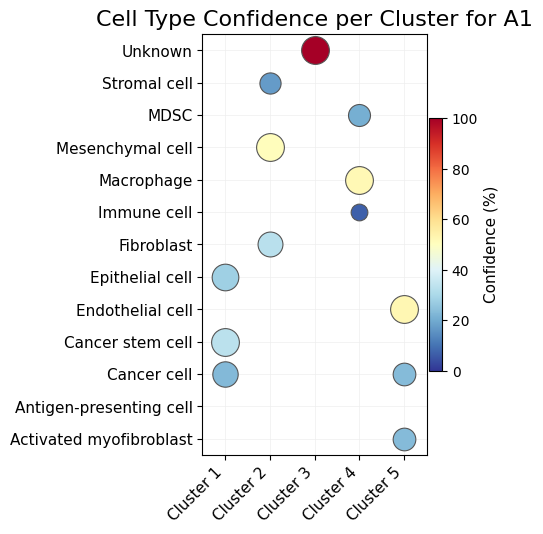

In [155]:
# Keep top 3 cell types per cluster
top3_per_cluster = {}
for cluster in identity_df.index:
    top3 = identity_df.loc[cluster].nlargest(3)
    top3_per_cluster[cluster] = top3

# Rebuild a filtered df with only the union of top-3 cell types across all clusters
top3_celltypes = sorted(set(ct for top3 in top3_per_cluster.values() for ct in top3.index))
identity_df_filtered = identity_df[top3_celltypes]
identity_df_norm = identity_df_filtered.div(identity_df_filtered.max(axis=1), axis=0) * 100

# Rename long cell type names
name_map = {
    "Myeloid derived suppressor cell (MDSC)": "MDSC",
}
identity_df_filtered = identity_df_filtered.rename(columns=name_map)
identity_df_norm     = identity_df_norm.rename(columns=name_map)

# Update top3_per_cluster index to use new names too
top3_per_cluster = {
    cluster: top3.rename(index=name_map)
    for cluster, top3 in top3_per_cluster.items()
}

fig, ax = plt.subplots(figsize=(max(5, len(identity_df_norm.index) * 0.4),
                                max(5, len(top3_celltypes) * 0.4)))

scatter = None
for i, cluster in enumerate(identity_df_norm.index):
    for j, ct in enumerate(identity_df_norm.columns):
        val_norm = identity_df_norm.loc[cluster, ct]
        val_raw  = identity_df_filtered.loc[cluster, ct]

        if ct not in top3_per_cluster[cluster].index:
            continue

        size = (np.sqrt(val_norm) / np.sqrt(100)) * 400

        scatter = ax.scatter(
            i, j,
            s=size,
            c=[val_raw],
            cmap="RdYlBu_r",
            vmin=0, vmax=100,
            linewidths=0.8,
            edgecolors="#555555",
            zorder=3
        )

if scatter:
    cbar = plt.colorbar(scatter, ax=ax, shrink=0.6, pad=0.01)
    cbar.set_label("Confidence (%)", fontsize=11)

ax.set_xticks(range(len(identity_df_filtered.index)))
ax.set_xticklabels([f"Cluster {c}" for c in identity_df_filtered.index], rotation=45, ha="right", fontsize=11)
ax.set_yticks(range(len(identity_df_filtered.columns)))
ax.set_yticklabels(identity_df_filtered.columns, rotation=0, ha="right", fontsize=11)

ax.set_xlim(-0.5, len(identity_df_filtered.index) - 0.5)
ax.set_ylim(-0.5, len(identity_df_filtered.columns) - 0.5)
ax.grid(True, color="#EEEEEE", linewidth=0.5, zorder=0)
ax.set_facecolor("white")

plt.tight_layout()
if a1:
    plt.title("Cell Type Confidence per Cluster for A1", fontsize=16)
    plt.savefig(current_path / "figure" / "cluster_celltype_dotplot_A1.png", dpi=180, bbox_inches="tight")
else:
    plt.title("Cell Type Confidence per Cluster for D1", fontsize=16)
    plt.savefig(current_path / "figure" / "cluster_celltype_dotplot_D1.png", dpi=180, bbox_inches="tight")

plt.show()

In [151]:
# ── 6. SUMMARY DATAFRAME ─────────────────────────────────────────────────────

records = []
for cluster, ranking in cluster_identity_v2.items():
    best_ct, best_pct = ranking[0]
    records.append({
        "cluster"         : cluster,
        "best_cell_type"  : best_ct,
        "confidence_pct"  : round(best_pct, 2),
        "top3_ranking"    : " | ".join(f"{ct} ({p:.1f}%)" for ct, p in ranking[:3]),
    })

summary_df = pd.DataFrame(records).set_index("cluster")
print("\n\n══ SUMMARY ══════════════════════════════════════")
print(summary_df.to_string())



══ SUMMARY ══════════════════════════════════════
           best_cell_type  confidence_pct                                                                           top3_ranking
cluster                                                                                                                         
1        Cancer stem cell           33.08               Cancer stem cell (33.1%) | Epithelial cell (28.0%) | Cancer cell (23.0%)
2        Mesenchymal cell           50.50                   Mesenchymal cell (50.5%) | Fibroblast (32.5%) | Stromal cell (17.0%)
3                 Unknown          100.00                                                                       Unknown (100.0%)
4              Macrophage           52.25  Macrophage (52.2%) | Myeloid derived suppressor cell (MDSC) (20.5%) | Monocyte (6.8%)
5        Endothelial cell           52.66       Endothelial cell (52.7%) | Cancer cell (23.3%) | Activated myofibroblast (23.3%)


In [ ]:
with h5py.File(file_path, "r") as f:
    data = f["matrix/data"][:]
    indices = f["matrix/indices"][:]
    indptr = f["matrix/indptr"][:]
    shape = f["matrix/shape"][:]

# Build sparse count matrix
matrix = sparse.csc_matrix((data, indices, indptr), shape=shape)
print(matrix.shape)

(38606, 167450)


C1 : Cancer cell
C2 : Mesenchymal
C3 : Unkown
C4 : Macrophage
C5 : Endothelial

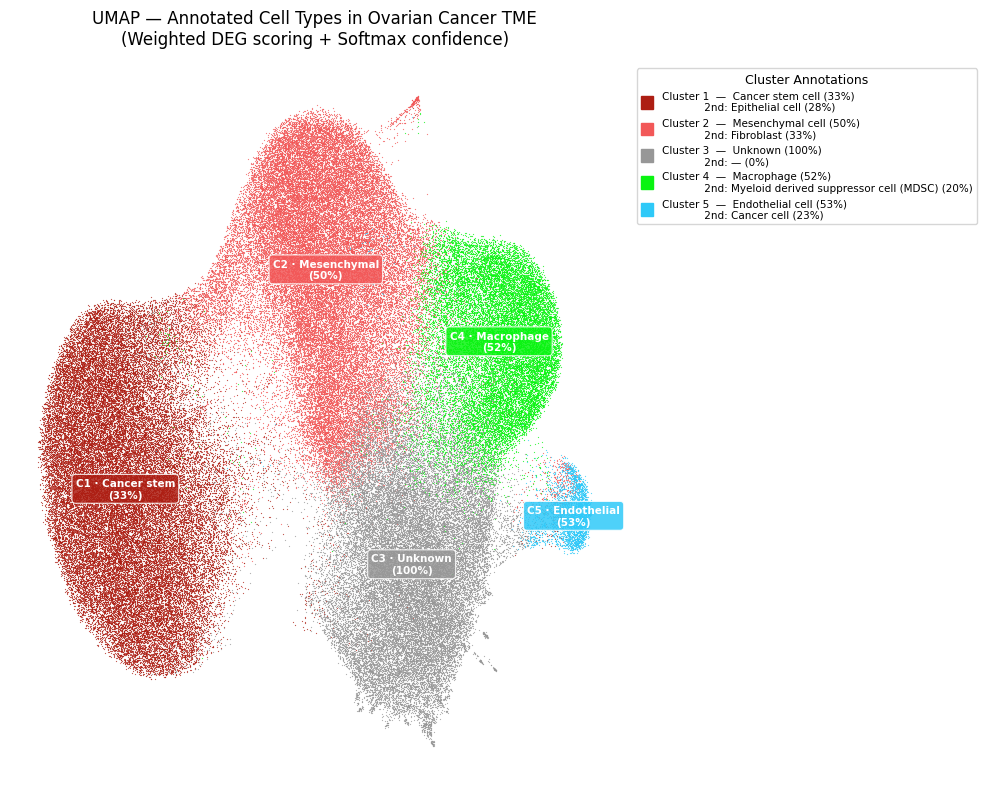

In [152]:
import matplotlib.patches as mpatches

# PLOT 1 — UMAP

cluster_labels = {}
for cluster, ranking in cluster_identity_v2.items():
    best_ct, best_pct = ranking[0]
    short = best_ct.replace(" cell", "").replace(" Cell", "")
    cluster_labels[cluster] = f"C{cluster} · {short}\n({best_pct:.0f}%)"


centroids = (
    umap_df.groupby("Cluster")[["UMAP-1", "UMAP-2"]]
    .median()
    .to_dict("index")
)

fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor("#FFFFFF")
ax.set_facecolor("#FFFFFF")

for cluster in sorted(umap_df["Cluster"].unique()):
    sub = umap_df[umap_df["Cluster"] == cluster]
    ax.scatter(
        sub["UMAP-1"], sub["UMAP-2"],
        c=custom_palette[cluster],
        s=0.8,
        linewidths=0,
        alpha=0.75,
        rasterized=True,
        label=cluster,
    )

for cluster, centroid in centroids.items():
    label_text = cluster_labels.get(cluster, f"C{cluster}")
    x, y = centroid["UMAP-1"], centroid["UMAP-2"]
    ax.text(
        x, y, label_text,
        fontsize=7.5,
        color="white",
        fontweight="bold",
        ha="center", va="center",
        bbox=dict(
            boxstyle="round,pad=0.35",
            facecolor=custom_palette[cluster],
            edgecolor="white",
            linewidth=0.8,
            alpha=0.85,
        ),
        zorder=10,
    )

legend_handles = []
for cluster in sorted(custom_palette.keys()):
    best_ct, best_pct = cluster_identity_v2[cluster][0]
    top2_ct, top2_pct = cluster_identity_v2[cluster][1] if len(cluster_identity_v2[cluster]) > 1 else ("—", 0)
    legend_label = (
        f"Cluster {cluster}  —  {best_ct} ({best_pct:.0f}%)\n"
        f"             2nd: {top2_ct} ({top2_pct:.0f}%)"
    )
    legend_handles.append(mpatches.Patch(color=custom_palette[cluster], label=legend_label))

leg = ax.legend(
    handles=legend_handles,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=True,
    facecolor="white",
    edgecolor="#CCCCCC",
    labelcolor="black",
    fontsize=7.5,
    title="Cluster Annotations",
    title_fontsize=9,
    handlelength=1.2,
    handleheight=1.5,
)
leg.get_title().set_color("black")

ax.set_xlabel("UMAP 1", fontsize=10)
ax.set_ylabel("UMAP 2", fontsize=10)
ax.set_title(
    "UMAP — Annotated Cell Types in Ovarian Cancer TME\n"
    "(Weighted DEG scoring + Softmax confidence)",
    fontsize=12, pad=14,
)
ax.tick_params(colors="#666666")
for spine in ax.spines.values():
    spine.set_edgecolor("#333")
plt.axis("off")

plt.tight_layout()
plt.savefig("umap_annotated.png", dpi=180, bbox_inches="tight",
            facecolor=fig.get_facecolor())
if a1 :
    plt.savefig(current_path / "figure" / "umap_clusters_A1_annotated.png", dpi=180, bbox_inches="tight")

else:    
    plt.savefig(current_path / "figure" / "umap_clusters_D1_annotated.png", dpi=180, bbox_inches="tight")
plt.show()





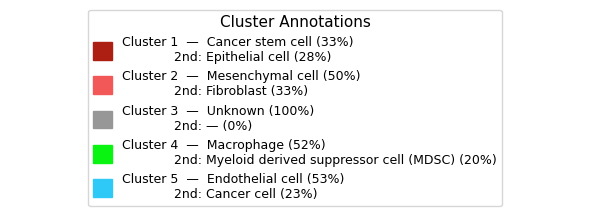

In [153]:
# PLOT 2 - Only the legend as a standalone figure for the powerpoint presentation
fig, ax = plt.subplots(figsize=(6, len(cluster_identity_v2) * 0.4))
fig.patch.set_facecolor("#FFFFFF")
ax.set_facecolor("#FFFFFF")
legend_handles = []
for cluster in sorted(custom_palette.keys()):
    best_ct, best_pct = cluster_identity_v2[cluster][0]
    top2_ct, top2_pct = cluster_identity_v2[cluster][1] if len(cluster_identity_v2[cluster]) > 1 else ("—", 0)
    legend_label = (
        f"Cluster {cluster}  —  {best_ct} ({best_pct:.0f}%)\n"
        f"             2nd: {top2_ct} ({top2_pct:.0f}%)"
    )
    legend_handles.append(mpatches.Patch(color=custom_palette[cluster], label=legend_label))
leg = ax.legend(
    handles=legend_handles,
    loc="center",
    frameon=True,
    facecolor="white",
    edgecolor="#CCCCCC",
    labelcolor="black",
    fontsize=9,
    title="Cluster Annotations",
    title_fontsize=11,
    handlelength=1.5,
    handleheight=1.8,
)
leg.get_title().set_color("black")
ax.axis("off")
plt.tight_layout()
if a1:
    plt.savefig(current_path / "figure" / "umap_legend_A1.png", dpi=180, bbox_inches="tight",
                facecolor=fig.get_facecolor())
if d1:
    plt.savefig(current_path / "figure" / "umap_legend_D1.png", dpi=180, bbox_inches="tight",
                facecolor=fig.get_facecolor())
plt.show()

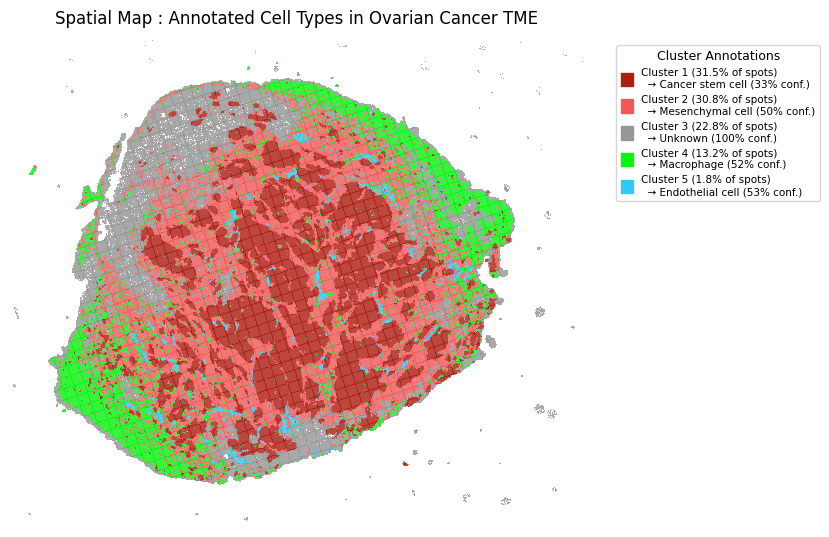

In [154]:
# PLOT 2 — SPATIAL MAP

fig, ax = plt.subplots(figsize=(8, 8))
fig.patch.set_facecolor("#FFFFFF")
ax.set_facecolor("#FFFFFF")

for cluster in sorted(plot_df["Cluster"].unique()):
    sub = plot_df[plot_df["Cluster"] == cluster]
    ax.scatter(
        sub["pxl_col_in_fullres"],
        sub["pxl_row_in_fullres"],
        c=custom_palette[cluster],
        s=0.7,
        linewidths=0,
        alpha=0.85,
        rasterized=True,
    )

ax.invert_yaxis()
ax.set_aspect("equal")
if a1:
    plt.xlim(0, 20000)
    plt.ylim(0, 17000)


legend_handles = []
for cluster in sorted(cluster_percentages.index):
    best_ct, best_pct = cluster_identity_v2[cluster][0]
    label = (
        f"Cluster {cluster} ({cluster_percentages[cluster]:.1f}% of spots)\n"
        f"  → {best_ct} ({best_pct:.0f}% conf.)"
    )
    legend_handles.append(mpatches.Patch(color=custom_palette[cluster], label=label))

leg = ax.legend(
    handles=legend_handles,
    title="Cluster Annotations",
    title_fontsize=9,
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    frameon=True,
    facecolor="white",
    edgecolor="#CCCCCC",
    labelcolor="black",
    fontsize=7.5,
    handlelength=1.2,
    handleheight=1.6,
)
leg.get_title().set_color("black")

ax.set_title(
    "Spatial Map : Annotated Cell Types in Ovarian Cancer TME",
    fontsize=12, pad=12,
)
ax.set_xlabel("X ", fontsize=9)
ax.set_ylabel("Y", fontsize=9)
ax.tick_params(colors="#555")
for spine in ax.spines.values():
    spine.set_edgecolor("#333")

plt.tight_layout()
plt.savefig("spatial_annotated.png", dpi=180,
            bbox_inches="tight", facecolor=fig.get_facecolor())
plt.axis("off")

if a1:
    plt.gcf().set_size_inches(10, 10)
    plt.savefig(current_path / "figure" / "spatial_clusters_A1_annotated.png", bbox_inches="tight")
else:
    plt.gcf().set_size_inches(16, 16)
    plt.savefig(current_path / "figure" / "spatial_clusters_D1_annotated.png", bbox_inches="tight")

plt.show()
